# Diagrams for theory section

We set out to create diagrams for the methodology of our tests.

In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt

### BSADF

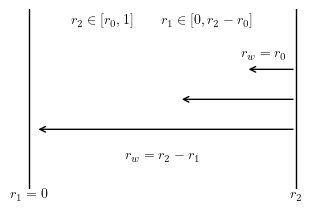

In [23]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(3,2), constrained_layout=True)

# Positions
x_left = 1
x_right = 9

# Tight horizontal limits around the actual drawing area
ax.set_xlim(x_left - 0.15, x_right + 0.15)
ax.set_ylim(0, 6)

# Remove axes
ax.axis('off')

# Draw vertical axes
ax.plot([x_left, x_left], [0, 6], color='black', linewidth=1)
ax.plot([x_right, x_right], [0, 6], color='black', linewidth=1)

# Axis labels
ax.text(x_left, -0.3, r"$r_1 = 0$", ha='center')
ax.text(x_right, -0.3, r"$r_2$", ha='center')

# Top annotation
ax.text(5, 5.5, r"$r_2 \in [r_0,1] \qquad r_1 \in [0, r_2 - r_0]$", ha='center')

# Window positions (short → long)
y_positions = [4, 3, 2]

# Make longest window almost axis-to-axis
starts = [7.5, 5.5, x_left + 0.2]

# Draw arrows
for y, start in zip(y_positions, starts):
    ax.annotate(
        "",
        xy=(start, y),
        xytext=(x_right, y),
        arrowprops=dict(arrowstyle="->", color='black', linewidth=1)
    )

# Label for shortest window (r_w = r_0)
short_start = starts[0]
short_end = x_right
short_mid = (short_start + short_end) / 2

ax.text(short_mid - 0.2, y_positions[0] + 0.4, r"$r_w = r_0$", ha='center') 

# General window length label
ax.text(5, 1, r"$r_w = r_2 - r_1$", ha='center')

# Save
plt.savefig("figures/bsadf_single_illustration.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

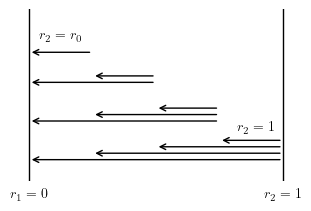

In [22]:
# LaTeX font settings
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

# Positions
x_left = 1
x_right = 9

# Tight horizontal limits around the actual drawing area
ax.set_xlim(x_left - 0.15, x_right + 0.15)
ax.set_ylim(0, 8)

# Remove axes
ax.axis('off')

# Draw vertical axes
ax.plot([x_left, x_left], [0, 8], color='black', linewidth=1)
ax.plot([x_right, x_right], [0, 8], color='black', linewidth=1)

# Axis labels
ax.text(x_left, -0.8, r"$r_1 = 0$", ha='center')
ax.text(x_right, -0.8, r"$r_2 = 1$", ha='center')

# ---- Define r2 positions (4 iterations) ----
r2_positions = [3, 5, 7, 9]  # [2.5, 4.5, 6.5, 9]  r2_positions = [3, 5, 7, 9]
y_groups = [6, 4.5, 3, 1.5] 

# Fixed minimum window length (same across all r2)
rw = 2.0 

for i, (x_r2, y_base) in enumerate(zip(r2_positions, y_groups)):

    # ---- FIRST ITERATION: r2 = r0 ----
    if i == 0:
        ax.annotate(
            "",
            xy=(x_left, y_base),
            xytext=(x_r2, y_base),
            arrowprops=dict(arrowstyle="->", color='black', linewidth=1)
        )
        
        # Label r2 = r0
        ax.text((x_left + x_r2)/2, y_base + 0.6, r"$r_2 = r_0$", ha='center')
        continue

    # ---- OTHER ITERATIONS ----

    # Startpunkter: venstre akse + alle tidligere r2
    start_points = [x_left] + r2_positions[:i]

    # Vend rækkefølgen så længste pil er øverst
    start_points = start_points[::-1]

    # Tegn pile (antal = iteration)
    for j, start in enumerate(start_points):
        ax.annotate(
            "",
            xy=(start, y_base + 0.4 - j*0.3),
            xytext=(x_r2, y_base + 0.4 - j*0.3),
            arrowprops=dict(arrowstyle="->", color='black', linewidth=1)
        )

    # Label r2 = 1 on last iteration (top arrow)
    if i == len(r2_positions) - 1:
        start_top = x_r2 - rw
        ax.text((start_top + x_r2)/2 + 0.15, y_base + 0.8, r"$r_2 = 1$", ha='center') 

# Save
plt.savefig("figures/bsadf_multiple_illustration.pdf", bbox_inches="tight", pad_inches=0.02)

plt.show()